# Models

### Read this carefully before starting

This file contains multiple models applied on the dataset, make a copy of the whole folder before proceeding
1. The code contains mistakes and generates comparisons between the wrong features (columns from the csv). Your job is to use `data_analysis.ipynb` to find the correct relationships to achieve maximum accuracy 

2. The code also uses wrong hyperparameters for the model training, along with comments saying `TODO` wherever there might be mistakes, use your machine learning knowledge and the comments to fix those mistakes

3. You are not encouraged to change anything else other than what is mentioned by `TODO` however you are also not forbidden, you can make extra models, change existing ones completely or do whatever you want in this notebook with this dataset

#### Submission:
After you have made all changes and have your final code, hit `Run All` at the top and a folder will be generated/updates saved at `./models`. Zip this folder and rename it to your delegation name only. Then send it to the provided link for final submission.

## Definitions

**Imports:**

In [1]:
# Standard library
import json
import os
import warnings

# Third-party
import joblib
import matplotlib.pyplot as plt
import pandas as pd

# Scikit-learn
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import ElasticNet, LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.svm import SVR

# Suppress convergence warnings from MLP
warnings.filterwarnings('ignore', category=UserWarning, module='sklearn')

**Helper functions to use in later blocks:**

In [2]:
def _to_json_serializable(value):
    if value is None or isinstance(value, (str, int, float, bool)):
        return value
    if hasattr(value, "item") and callable(getattr(value, "item")):
        try:
            return value.item()
        except Exception:
            pass
    if isinstance(value, dict):
        return {str(k): _to_json_serializable(v) for k, v in value.items()}
    if isinstance(value, (list, tuple, set)):
        return [_to_json_serializable(v) for v in value]
    return str(value)


def initialize_metrics(feature_cols):
    """Initialize the metrics JSON file with feature columns at the start."""
    MODEL_DIR = "../models"
    METRICS_PATH = os.path.join(MODEL_DIR, "model_metrics.json")
    
    metrics = {
        "feature_columns": list(feature_cols),
        "models": {}
    }
    
    with open(METRICS_PATH, "w") as f:
        json.dump(metrics, f, indent=4)
    
    print(f"Initialized metrics file with {len(feature_cols)} feature columns")


def evaluate_model(model_name, hyperparameters):
    MODEL_DIR = "../models"
    model_path = os.path.join(MODEL_DIR, model_name + ".joblib")

    if not os.path.exists(model_path):
        raise FileNotFoundError(f"Model file not found: {model_path}")

    model = joblib.load(model_path)

    global X_test, y_test

    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"Evaluation metrics for {model_name}:")
    print(f"MSE: {mse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"R^2: {r2:.4f}")

    METRICS_PATH = os.path.join(MODEL_DIR, "model_metrics.json")
    metrics = {}
    if os.path.exists(METRICS_PATH):
        with open(METRICS_PATH, "r") as f:
            metrics = json.load(f)

    if "models" not in metrics:
        metrics["models"] = {}

    metrics["models"][model_name] = {
        "MSE": float(mse),
        "MAE": float(mae),
        "R2": float(r2),
        "hyperparameters": _to_json_serializable(hyperparameters),
    }

    with open(METRICS_PATH, "w") as f:
        json.dump(metrics, f, indent=4)

    return y_pred


def plot_predictions(y_true, y_pred, model_name):
    plt.figure(figsize=(8, 6))
    plt.scatter(y_true, y_pred, alpha=0.6, edgecolors='k')
    plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2)
    plt.xlabel("Actual " + target_column)
    plt.ylabel("Predicted " + target_column)
    plt.title(f"Predicted vs Actual Values ({model_name})")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

## Read Data

In [3]:
# read the csv file
df = pd.read_csv("../data/dataset.csv")

target_column = "power_consumption" # do not change this line

feature_columns = ["uptime", "network_latency", "disk_io"]  # TODO find best features from data_analysis.ipynb

# Prepare data
X = df[feature_columns]
y = df[target_column]

# split data for train & test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# constants
model_name = ""
MODEL_DIR = "../models"

# Initialize metrics file with feature columns
initialize_metrics(feature_columns)

Initialized metrics file with 3 feature columns


## Polynomial Regression

Evaluation metrics for polynomial_regression:
MSE: 5818.6351
MAE: 58.6318
R^2: -0.2884


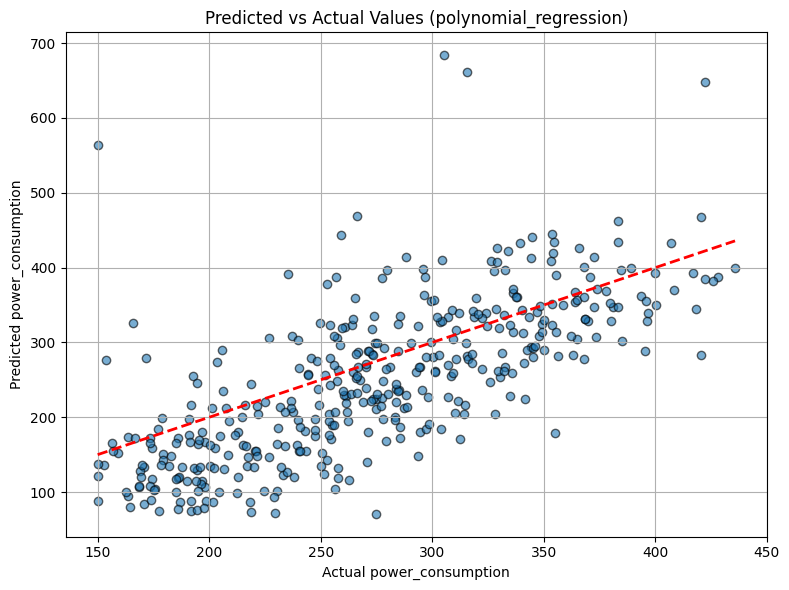

In [4]:
# Model save directory
model_name = "polynomial_regression"
MODEL_PATH = os.path.join(MODEL_DIR, model_name + ".joblib")

# TODO Hyperparameters
degree = 1              # experiment with different degrees, linear=1, quadratic=2, cubic=3 ...
include_bias = False    # bias means that the model can have a non-zero y-intercept

X_train_model = X_train[feature_columns]
X_test_model = X_test[feature_columns]

hyperparameters = {
    "degree": degree,
    "include_bias": include_bias,
    "fit_intercept": False,
    "features_used": feature_columns,
}

# Training model
model = make_pipeline(
    PolynomialFeatures(degree, include_bias=include_bias),
    LinearRegression(fit_intercept=False)  # TODO no intercept means always passing through origin, is that good or bad?
)
model.fit(X_train_model, y_train)

# Saving model
os.makedirs(MODEL_DIR, exist_ok=True)
joblib.dump(model, MODEL_PATH)

# Evaluate and plot
predictions = evaluate_model(model_name, hyperparameters)
plot_predictions(y_test, predictions, model_name)

## Random Forest Regression

Evaluation metrics for random_forest_regression:
MSE: 3286.2755
MAE: 47.1848
R^2: 0.2723


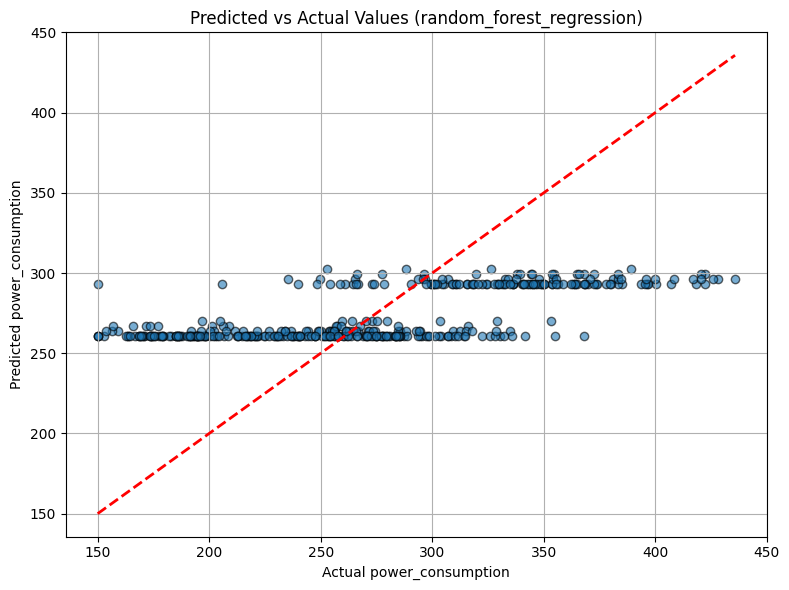

In [5]:
# Model save directory
model_name = "random_forest_regression"
MODEL_PATH = os.path.join(MODEL_DIR, model_name + ".joblib")

# TODO Hyperparameters (SUBOPTIMAL - extremely constrained, almost useless)
n_estimators = 3        # number of trees in the forest, is 3 too much or too less for a dataset with many features??
max_depth = 1           # how many levels each tree can have, more equals more complex training
min_samples_split = 100 # How many values are needed to split a tree, isn't 100 too high for a dataset with 2000 records??
min_samples_leaf = 50   # minimum number of samples required to be at a leaf node, too high i think
max_features = 0.2      # how many features to consider for split, try sqrt
random_state = 42       # Random seed for reproducibility, doesn't matter much here

X_train_model = X_train[feature_columns]
X_test_model = X_test[feature_columns]

hyperparameters = {
    "n_estimators": n_estimators,
    "max_depth": max_depth,
    "min_samples_split": min_samples_split,
    "min_samples_leaf": min_samples_leaf,
    "max_features": max_features,
    "random_state": random_state,
    "n_jobs": -1,
    "features_used": feature_columns,
}

# Training model
model = RandomForestRegressor(
    n_estimators=n_estimators,
    max_depth=max_depth,
    min_samples_split=min_samples_split,
    min_samples_leaf=min_samples_leaf,
    max_features=max_features,
    random_state=random_state,
    n_jobs=-1,
)
model.fit(X_train_model, y_train)

# Saving model
os.makedirs(MODEL_DIR, exist_ok=True)
joblib.dump(model, MODEL_PATH)

# Evaluate and plot
predictions = evaluate_model(model_name, hyperparameters)
plot_predictions(y_test, predictions, model_name)

## Multi-Layer-Perceptron Regression

Evaluation metrics for mlp_regressor:
MSE: 79033.9340
MAE: 272.9505
R^2: -16.5005


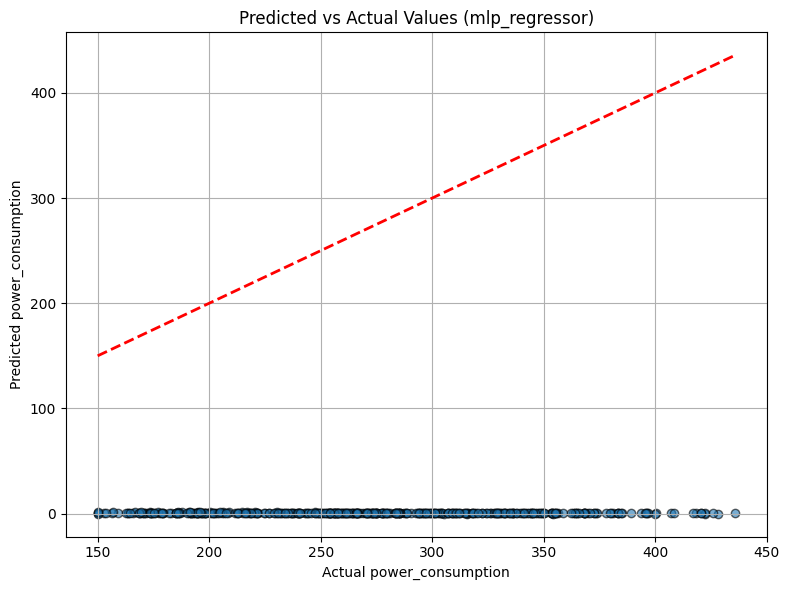

In [ ]:
# Model save directory
model_name = "mlp_regressor"
MODEL_PATH = os.path.join(MODEL_DIR, model_name + ".joblib")

# TODO Hyperparameters
hidden_layer_sizes = (4,)       # Number of neurons in one layer, maybe try more than yours  
activation = "tanh"             # activation function, can also try 'relu'
solver = "sgd"                  # optimizer, can also try 'adam'
max_iter = 30                   # how many times to train over the dataset, usually a huge number
random_state = 42               # Random seed for reproducibility, doesn't matter much here
alpha = 100.0                    # L2 regularization, maybe it should be the other way around or even lower
learning_rate_init = 0.0005     # Learning rate, try increasing by multiples of 2
early_stopping = True           # Stop training when validation score stops improving, dont change

X_train_model = X_train[feature_columns]
X_test_model = X_test[feature_columns]

hyperparameters = {
    "hidden_layer_sizes": hidden_layer_sizes,
    "activation": activation,
    "solver": solver,
    "max_iter": max_iter,
    "random_state": random_state,
    "alpha": alpha,
    "learning_rate_init": learning_rate_init,
    "early_stopping": early_stopping,
    "scaled": True,
    "features_used": feature_columns,
}

# Training model
model = make_pipeline(
    StandardScaler(),
    MLPRegressor(
        hidden_layer_sizes=hidden_layer_sizes,
        activation=activation,
        solver=solver,
        max_iter=max_iter,
        alpha=alpha,
        learning_rate_init=learning_rate_init,
        early_stopping=early_stopping,
        random_state=random_state,
    ),
)
model.fit(X_train_model, y_train)

# Saving model
os.makedirs(MODEL_DIR, exist_ok=True)
joblib.dump(model, MODEL_PATH)

# Evaluate and plot
predictions = evaluate_model(model_name, hyperparameters)
plot_predictions(y_test, predictions, model_name)

## Support Vector Regression

Evaluation metrics for svr_regressor:
MSE: 4219.1041
MAE: 53.5125
R^2: 0.0658


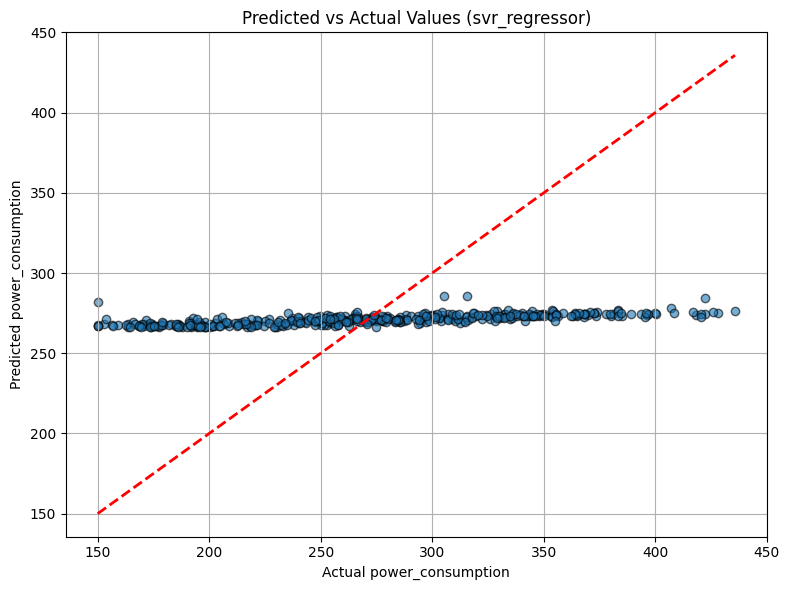

In [7]:
# Model save directory
model_name = "svr_regressor"
MODEL_PATH = os.path.join(MODEL_DIR, model_name + ".joblib")

# TODO Hyperparameters
kernel = "poly"         # Polynomial kernel, can also try 'rbf', if so remove the degree param yourself
degree = 1              # But degree 1 - just linear with extra overhead
C = 0.3                 # Low regularization, how about 1
epsilon = 15.0          # should be lower than 0.1
gamma = 0.01            # Low gamma, another option is 'scale' to adapt to data

X_train_model = X_train[feature_columns]
X_test_model = X_test[feature_columns]

hyperparameters = {
    "kernel": kernel,
    "degree": degree,
    "C": C,
    "epsilon": epsilon,
    "gamma": gamma,
    "scaled": True,
    "features_used": feature_columns,
}

# Training model
model = make_pipeline(
    StandardScaler(),
    SVR(kernel=kernel, degree=degree, C=C, epsilon=epsilon, gamma=gamma),
)
model.fit(X_train_model, y_train)

# Saving model
os.makedirs(MODEL_DIR, exist_ok=True)
joblib.dump(model, MODEL_PATH)

# Evaluate and plot
predictions = evaluate_model(model_name, hyperparameters)
plot_predictions(y_test, predictions, model_name)

## Elastic Net

Evaluation metrics for elastic_net_regression:
MSE: 3617.6217
MAE: 49.3958
R^2: 0.1989


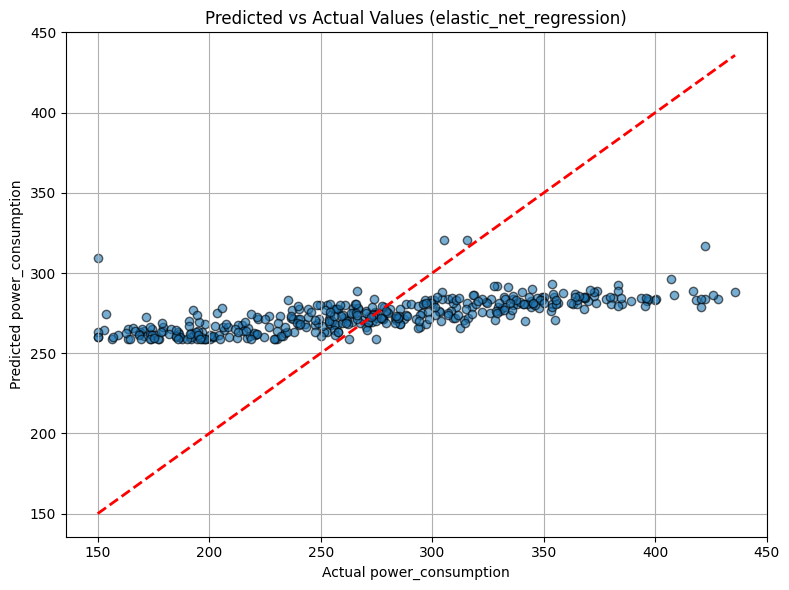

In [8]:
# Model save directory
model_name = "elastic_net_regression"
MODEL_PATH = os.path.join(MODEL_DIR, model_name + ".joblib")

# TODO Hyperparameters (SUBOPTIMAL - high regularization causes underfitting)
alpha = 15.0            # i think you should know about regularization by now, look at previous models
l1_ratio = 0.8          # regularization mix between L1 and L2, maybe try 50, 50
max_iter = 500          # idk what to put here, should work with other good parameters or you can just increase it you dont know what you're doing
random_state = 42       # Random seed for reproducibility, doesn't matter

X_train_model = X_train[feature_columns]
X_test_model = X_test[feature_columns]

hyperparameters = {
    "alpha": alpha,
    "l1_ratio": l1_ratio,
    "max_iter": max_iter,
    "random_state": random_state,
    "scaled": True,
    "features_used": feature_columns,
}

# Training model
model = make_pipeline(
    StandardScaler(),
    ElasticNet(alpha=alpha, l1_ratio=l1_ratio, max_iter=max_iter, random_state=random_state),
)
model.fit(X_train_model, y_train)

# Saving model
os.makedirs(MODEL_DIR, exist_ok=True)
joblib.dump(model, MODEL_PATH)

# Evaluate and plot
predictions = evaluate_model(model_name, hyperparameters)
plot_predictions(y_test, predictions, model_name)